Dataset shape: (522, 10)
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   22  female    2     own          little         moderate           5951   
1   45    male    2    free          little           little           7882   
2   53    male    2    free          little           little           4870   
3   35    male    3    rent          little         moderate           6948   
4   28    male    3     own          little         moderate           5234   

   Duration              Purpose  Risk  
0        48             radio/TV   bad  
1        42  furniture/equipment  good  
2        24                  car   bad  
3        36                  car  good  
4        30                  car   bad  

Sentiment Sample:
                                        Loan_Remarks  Sentiment_Polarity  \
0  Checking account frequently overdrawn, high de...                0.13   
1  Applicant has a stable employment history and ...                0.25   
2      

C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette={'good': '#2ecc71', 'bad': '#e74c3c'}, ax=axes[1])


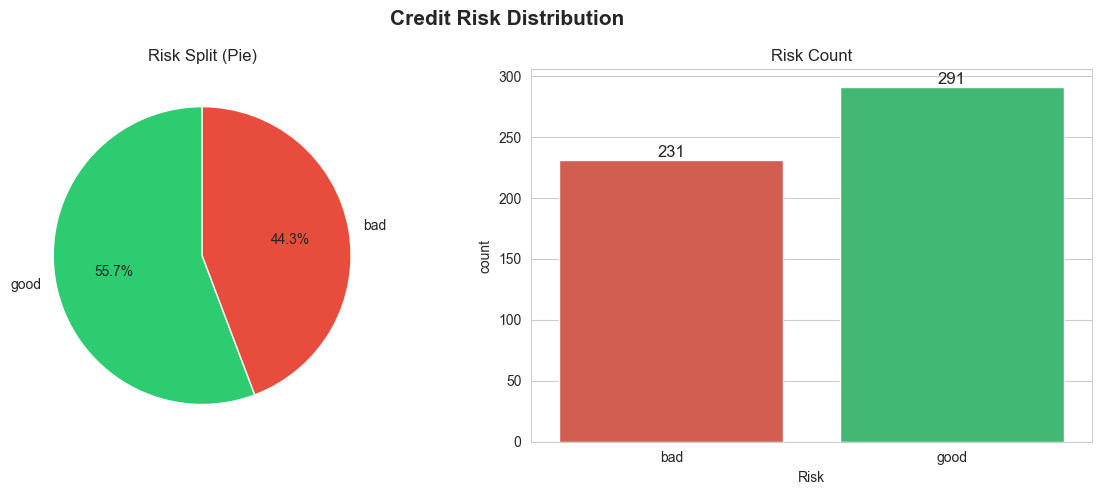

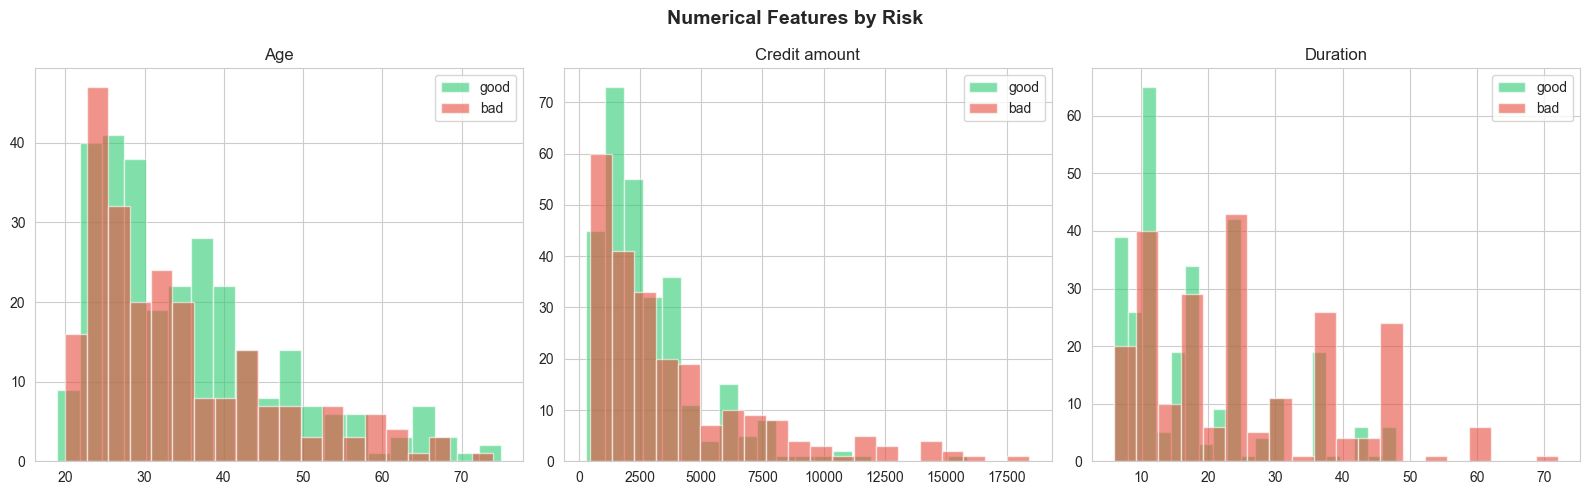

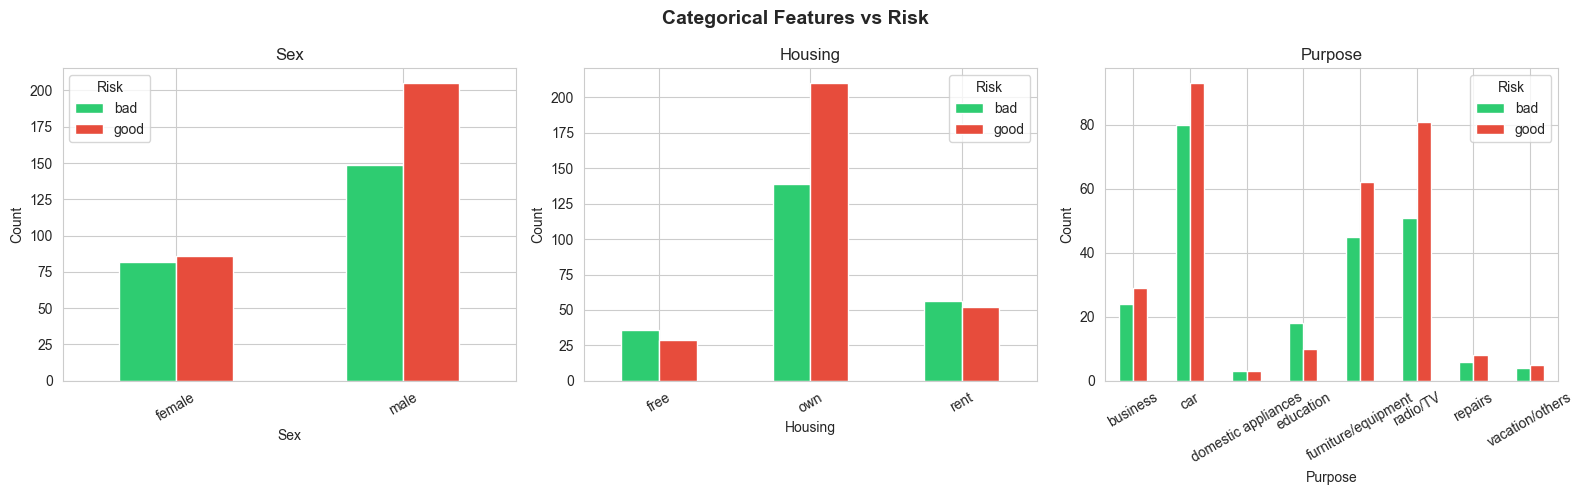

C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y='Credit amount', data=df,
C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y='Duration', data=df,


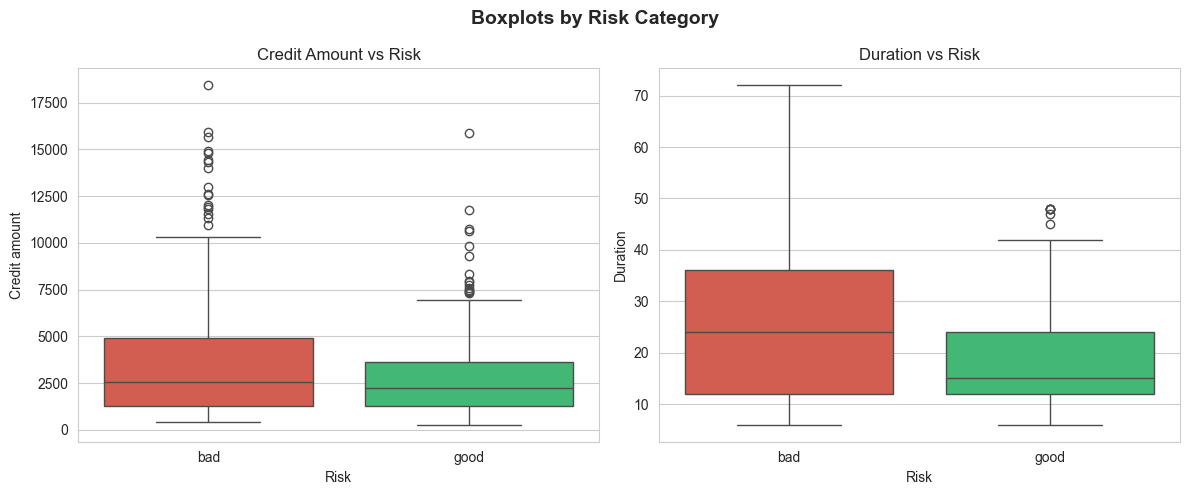

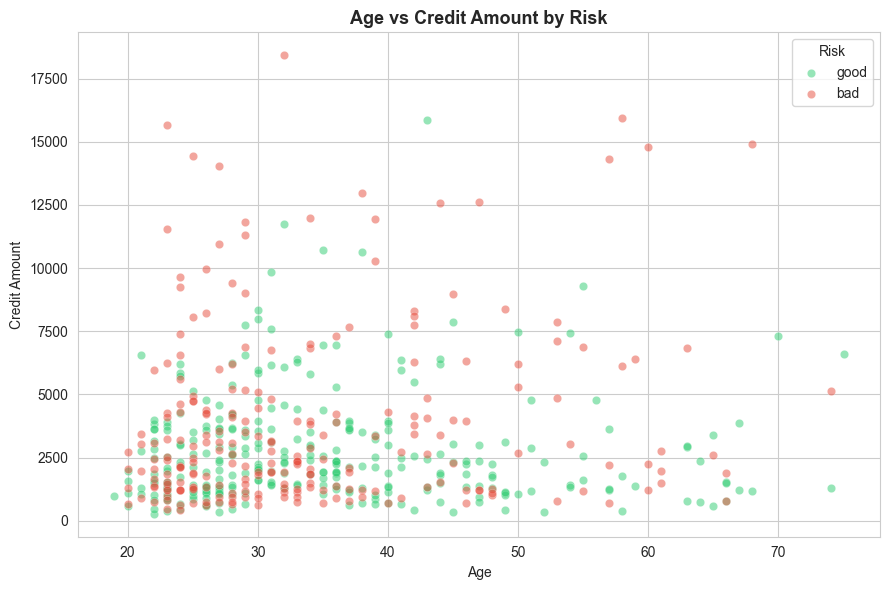

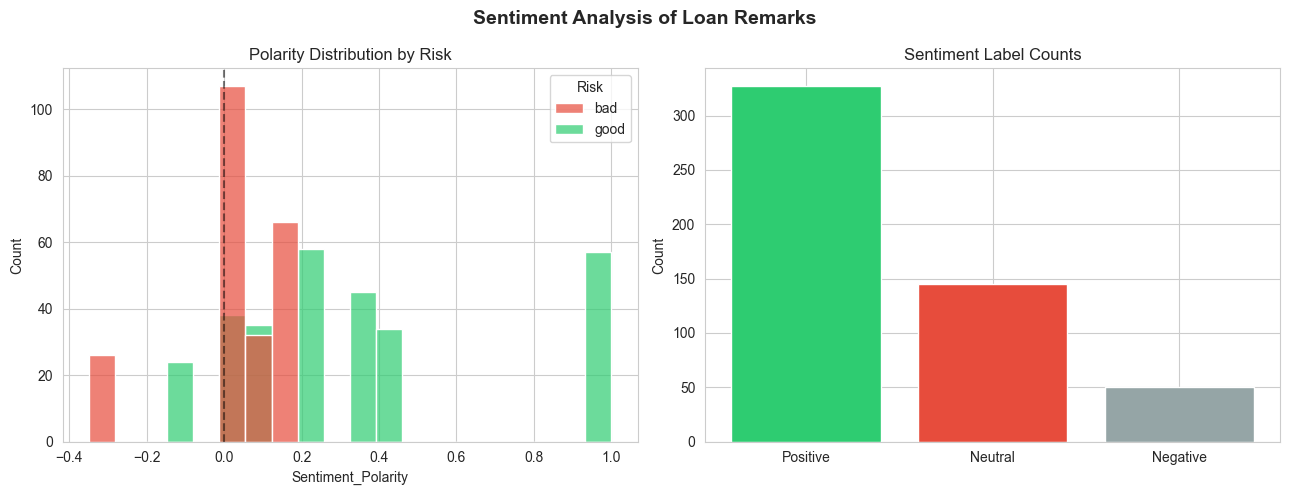

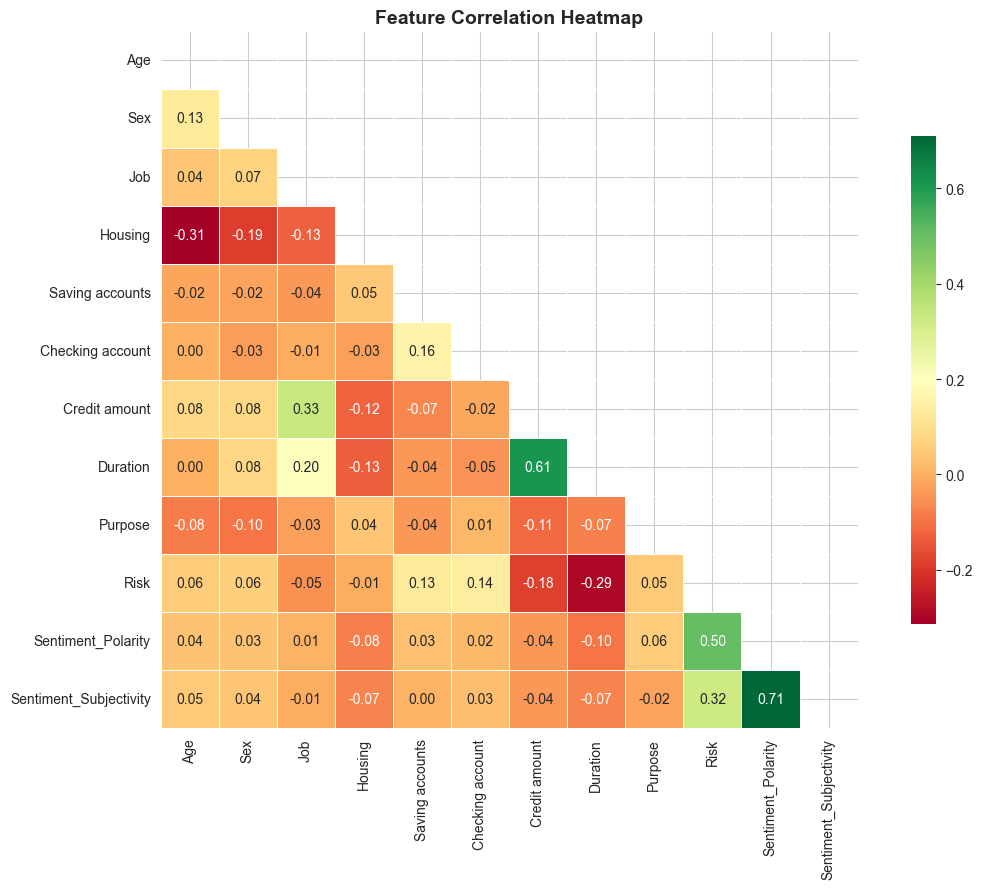


Training samples : 417
Test samples     : 105

Extra Trees → Accuracy: 0.9143 | ROC-AUC: 0.9694

Classification Report:
               precision    recall  f1-score   support

         Bad       0.85      0.98      0.91        46
        Good       0.98      0.86      0.92        59

    accuracy                           0.91       105
   macro avg       0.91      0.92      0.91       105
weighted avg       0.92      0.91      0.91       105



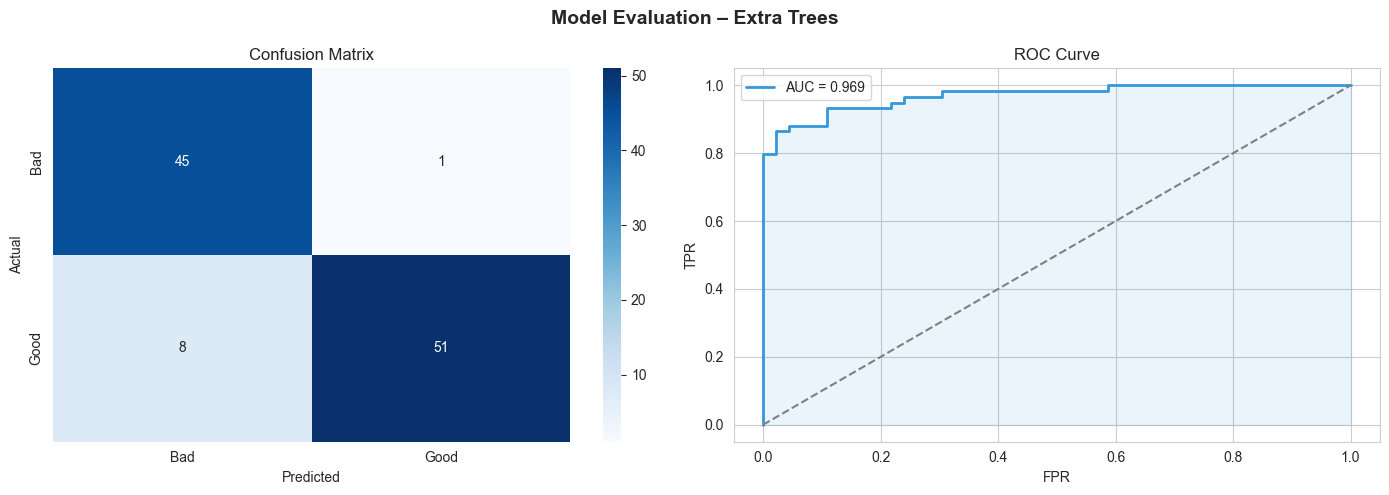

C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:266: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:267: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('feature_importance.png', dpi=150)
c:\Users\keert\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


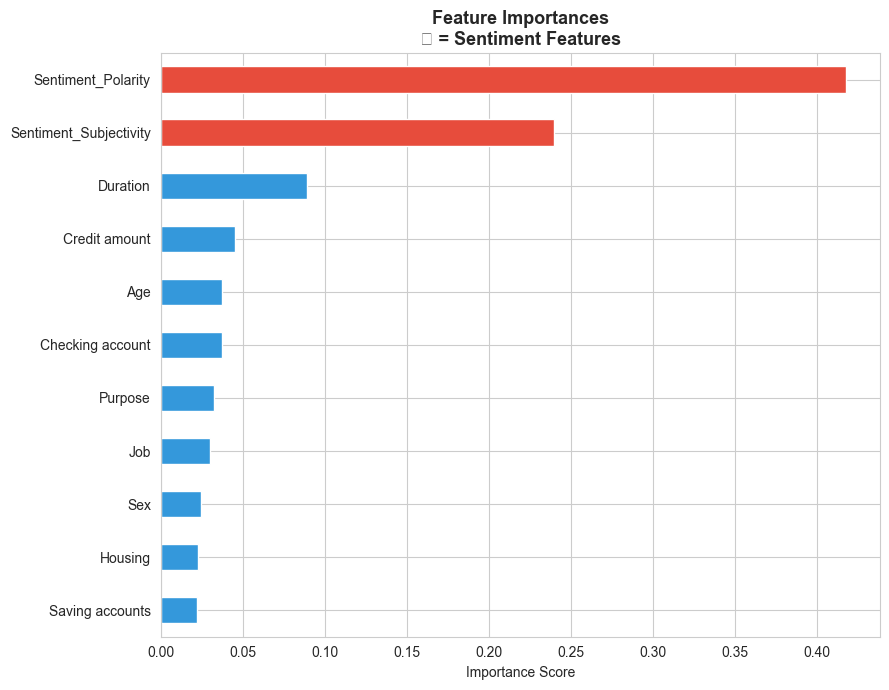


Computing SHAP values...
SHAP values shape (class 1): (105, 11)


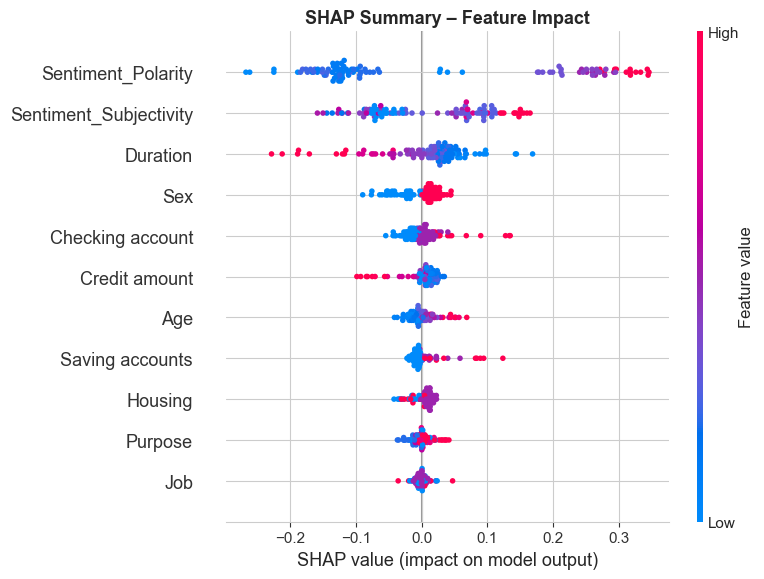

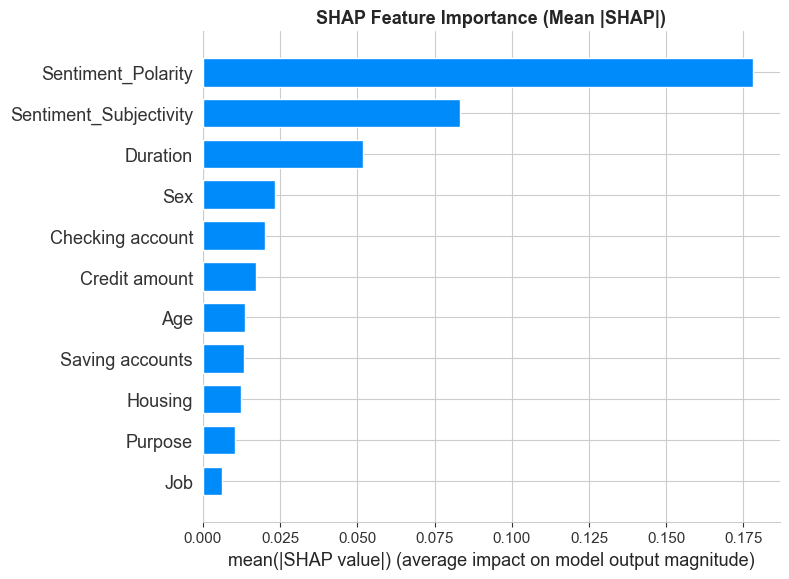

C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:329: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:329: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:330: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
C:\Users\keert\AppData\Local\Temp\ipykernel_20432\3337505615.py:330: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
c:\Users\keert\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kee

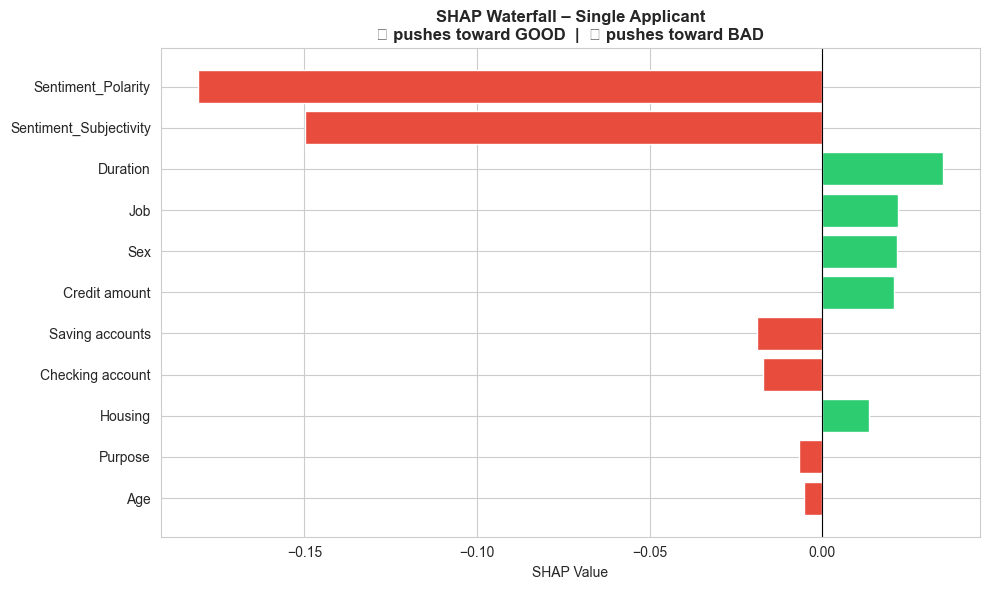

<Figure size 900x600 with 0 Axes>

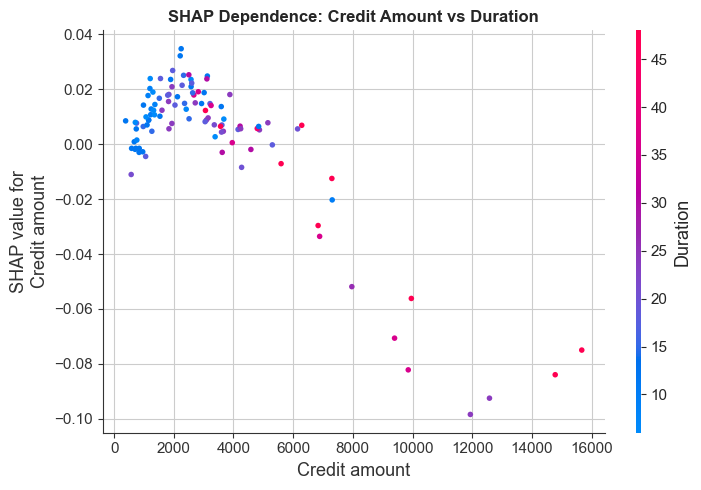

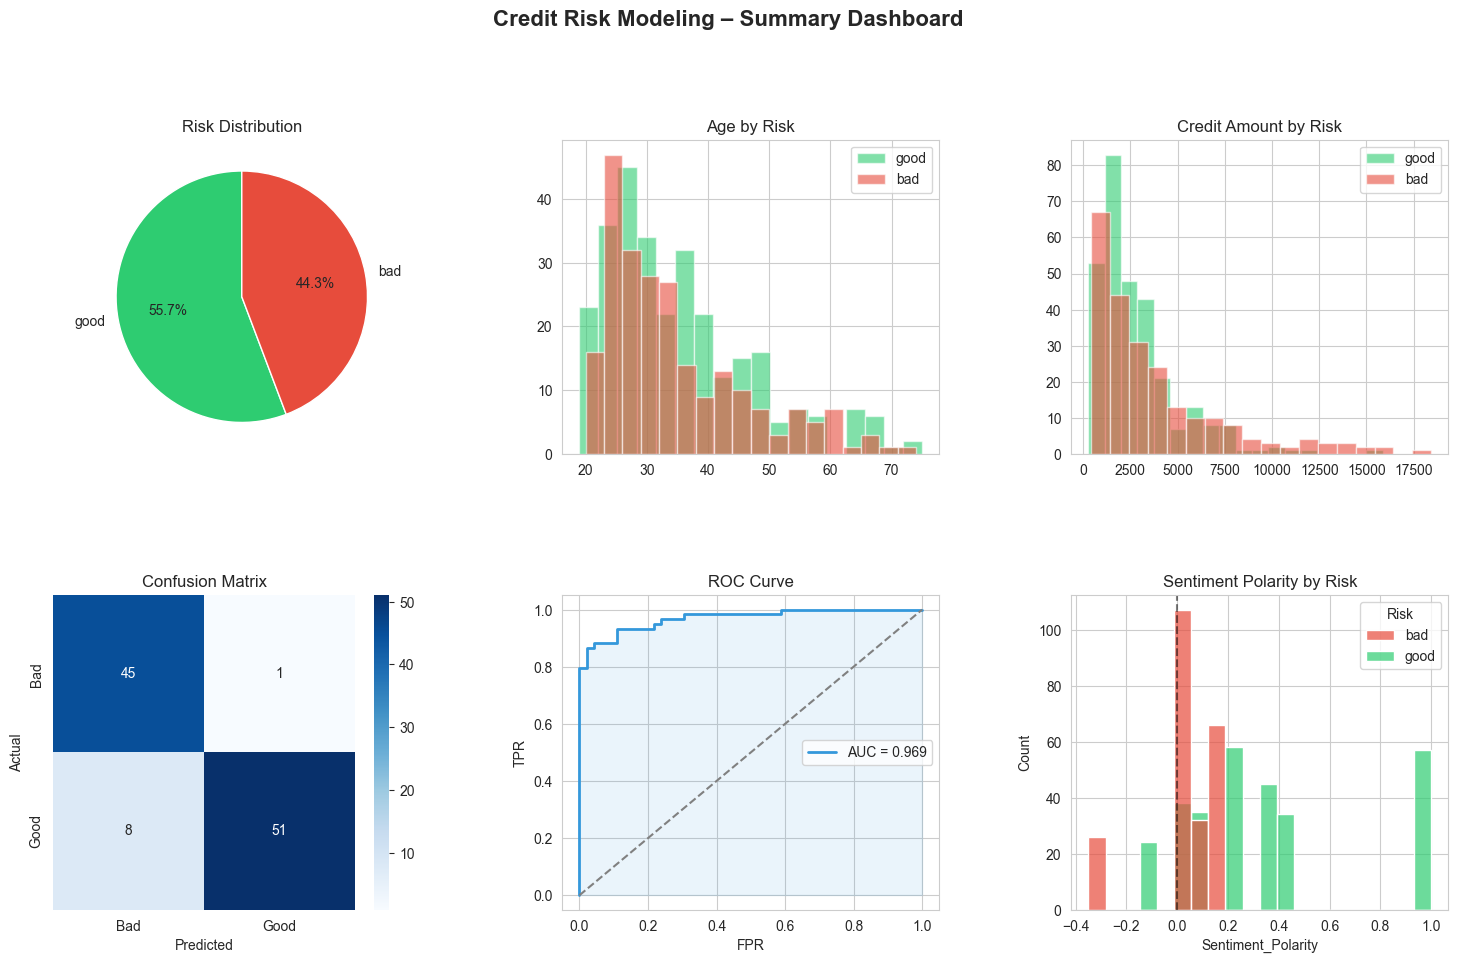


✅ All done! Files saved:
   • extra_trees_credit_model.pkl
   • eda_risk_distribution.png
   • eda_numerical_distributions.png
   • eda_categorical_vs_risk.png
   • eda_boxplots.png
   • eda_age_vs_credit.png
   • eda_correlation_heatmap.png
   • eda_sentiment_analysis.png
   • model_evaluation.png
   • feature_importance.png
   • shap_summary.png
   • shap_importance_bar.png
   • shap_waterfall.png
   • shap_dependence.png
   • summary_dashboard.png


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from textblob import TextBlob

# ─────────────────────────────────────────────
# SETTINGS
# ─────────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
COLORS = ['#2ecc71', '#e74c3c']

# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv('german_credit_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Dataset shape:", df.shape)
print(df.head())

# ─────────────────────────────────────────────
# 2. SENTIMENT ANALYSIS ON SIMULATED LOAN REMARKS
# ─────────────────────────────────────────────
good_remarks = [
    "Applicant has a stable employment history and consistent savings.",
    "Strong repayment track record and reliable income source.",
    "Customer maintains a healthy checking account with regular deposits.",
    "Excellent credit history with no defaults observed.",
    "Applicant demonstrates responsible financial behavior.",
    "No outstanding debts and a solid job tenure.",
    "Loan purpose is well-justified with adequate collateral.",
    "Customer appears financially disciplined and low-risk.",
]
bad_remarks = [
    "Applicant has irregular income and multiple missed payments.",
    "Checking account frequently overdrawn, high default risk.",
    "Customer has a history of late payments and poor savings habit.",
    "Loan purpose unclear, financial profile raises concerns.",
    "High existing debt-to-income ratio observed.",
    "Unstable employment record with frequent job changes.",
    "Multiple loan applications detected in short time period.",
    "Insufficient collateral to cover the requested loan amount.",
]

random.seed(42)
df['Loan_Remarks'] = df['Risk'].apply(
    lambda r: random.choice(good_remarks) if r == 'good' else random.choice(bad_remarks)
)
df['Sentiment_Polarity']     = df['Loan_Remarks'].apply(lambda t: TextBlob(t).sentiment.polarity)
df['Sentiment_Subjectivity'] = df['Loan_Remarks'].apply(lambda t: TextBlob(t).sentiment.subjectivity)
df['Sentiment_Label']        = df['Sentiment_Polarity'].apply(
    lambda p: 'Positive' if p > 0 else ('Negative' if p < 0 else 'Neutral')
)
print("\nSentiment Sample:")
print(df[['Loan_Remarks', 'Sentiment_Polarity', 'Sentiment_Label']].head(5))

# ─────────────────────────────────────────────
# 3. EDA + VISUALIZATIONS
# ─────────────────────────────────────────────

# 3a. Risk Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Credit Risk Distribution', fontsize=15, fontweight='bold')
risk_counts = df['Risk'].value_counts()
axes[0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=COLORS, startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Risk Split (Pie)')
sns.countplot(x='Risk', data=df, palette={'good': '#2ecc71', 'bad': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Risk Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('eda_risk_distribution.png', dpi=150)
plt.show()
plt.close()

# 3b. Numerical Feature Distributions
num_cols = ['Age', 'Credit amount', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Numerical Features by Risk', fontsize=14, fontweight='bold')
for i, col in enumerate(num_cols):
    for risk, color in zip(['good', 'bad'], COLORS):
        axes[i].hist(df[df['Risk'] == risk][col], bins=20,
                     alpha=0.6, color=color, label=risk, edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.savefig('eda_numerical_distributions.png', dpi=150)
plt.show()
plt.close()

# 3c. Categorical Features vs Risk
cat_cols = ['Sex', 'Housing', 'Purpose']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Categorical Features vs Risk', fontsize=14, fontweight='bold')
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Risk'])
    ct.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='white', rot=30)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Risk')
plt.tight_layout()
plt.savefig('eda_categorical_vs_risk.png', dpi=150)
plt.show()
plt.close()

# 3d. Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Boxplots by Risk Category', fontsize=14, fontweight='bold')
sns.boxplot(x='Risk', y='Credit amount', data=df,
            palette={'good': '#2ecc71', 'bad': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Credit Amount vs Risk')
sns.boxplot(x='Risk', y='Duration', data=df,
            palette={'good': '#2ecc71', 'bad': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Duration vs Risk')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150)
plt.show()
plt.close()

# 3e. Age vs Credit Amount Scatter
plt.figure(figsize=(9, 6))
for risk, color in zip(['good', 'bad'], COLORS):
    subset = df[df['Risk'] == risk]
    plt.scatter(subset['Age'], subset['Credit amount'],
                alpha=0.5, c=color, label=risk, edgecolors='white', linewidths=0.3)
plt.title('Age vs Credit Amount by Risk', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Credit Amount')
plt.legend(title='Risk')
plt.tight_layout()
plt.savefig('eda_age_vs_credit.png', dpi=150)
plt.show()
plt.close()

# 3f. Sentiment Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sentiment Analysis of Loan Remarks', fontsize=14, fontweight='bold')
sns.histplot(data=df, x='Sentiment_Polarity', hue='Risk',
             palette={'good': '#2ecc71', 'bad': '#e74c3c'},
             bins=20, alpha=0.7, ax=axes[0])
axes[0].set_title('Polarity Distribution by Risk')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
sentiment_counts = df['Sentiment_Label'].value_counts()
axes[1].bar(sentiment_counts.index, sentiment_counts.values,
            color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='white')
axes[1].set_title('Sentiment Label Counts')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_sentiment_analysis.png', dpi=150)
plt.show()
plt.close()

# ─────────────────────────────────────────────
# 4. ENCODING
# ─────────────────────────────────────────────
df_model = df.copy()
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    joblib.dump(le, f'{col}_encoder.pkl')

le_target = LabelEncoder()
df_model['Risk'] = le_target.fit_transform(df_model['Risk'])
joblib.dump(le_target, 'target_encoder.pkl')

df_model.drop(columns=['Loan_Remarks', 'Sentiment_Label'], inplace=True)

# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()
plt.close()

# ─────────────────────────────────────────────
# 5. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

# ─────────────────────────────────────────────
# 6. MODEL TRAINING
# ─────────────────────────────────────────────
et_params_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}
grid = GridSearchCV(
    ExtraTreesClassifier(random_state=1, class_weight='balanced'),
    et_params_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)
best_et  = grid.best_estimator_
y_pred   = best_et.predict(X_test)
y_proba  = best_et.predict_proba(X_test)[:, 1]
et_acc   = accuracy_score(y_test, y_pred)
et_auc   = roc_auc_score(y_test, y_proba)

print(f"\nExtra Trees → Accuracy: {et_acc:.4f} | ROC-AUC: {et_auc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

joblib.dump(best_et, 'extra_trees_credit_model.pkl')

# Confusion Matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation – Extra Trees', fontsize=14, fontweight='bold')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {et_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
plt.close()

# Feature Importance
feat_imp = pd.Series(best_et.feature_importances_, index=X.columns).sort_values(ascending=True)
bar_colors = ['#e74c3c' if 'Sentiment' in f else '#3498db' for f in feat_imp.index]
plt.figure(figsize=(9, 7))
feat_imp.plot(kind='barh', color=bar_colors)
plt.title('Feature Importances\n🔴 = Sentiment Features', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
plt.close()

# ─────────────────────────────────────────────
# 7. SHAP EXPLAINABILITY
# ─────────────────────────────────────────────
print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(best_et)
shap_values = explainer.shap_values(X_test)

# Safely extract SHAP values for class 1 (Good Risk)
def get_shap_class1(sv):
    if isinstance(sv, list):
        return np.array(sv[1])          # binary: [class0, class1]
    arr = np.array(sv)
    if arr.ndim == 3:
        return arr[:, :, 1]             # (samples, features, classes)
    return arr                          # already (samples, features)

sv_class1 = get_shap_class1(shap_values)
print("SHAP values shape (class 1):", sv_class1.shape)

expected_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# 7a. SHAP Summary Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(sv_class1, X_test, plot_type='dot', show=False)
plt.title('SHAP Summary – Feature Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# 7b. SHAP Summary Bar
plt.figure(figsize=(10, 7))
shap.summary_plot(sv_class1, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# 7c. SHAP Waterfall – Single Applicant (fully manual, no SHAP plot functions)
single_shap = sv_class1[0]                        # 1D array of shape (n_features,)
single_shap = np.array(single_shap).flatten()     # guarantee 1D

features  = X_test.columns.tolist()
shap_df   = pd.DataFrame({'Feature': features, 'SHAP Value': single_shap})
shap_df   = shap_df.reindex(shap_df['SHAP Value'].abs().sort_values().index)
bar_clrs  = ['#e74c3c' if v < 0 else '#2ecc71' for v in shap_df['SHAP Value']]

plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['SHAP Value'], color=bar_clrs, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('SHAP Waterfall – Single Applicant\n🟢 pushes toward GOOD  |  🔴 pushes toward BAD',
          fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# 7d. SHAP Dependence Plot
plt.figure(figsize=(9, 6))
shap.dependence_plot('Credit amount', sv_class1, X_test,
                     interaction_index='Duration', show=False)
plt.title('SHAP Dependence: Credit Amount vs Duration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ─────────────────────────────────────────────
# 8. SUMMARY DASHBOARD
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Credit Risk Modeling – Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        colors=COLORS, startangle=90, wedgeprops=dict(edgecolor='white'))
ax1.set_title('Risk Distribution')

ax2 = fig.add_subplot(gs[0, 1])
for risk, color in zip(['good', 'bad'], COLORS):
    ax2.hist(df[df['Risk'] == risk]['Age'], bins=18, alpha=0.6, color=color, label=risk)
ax2.set_title('Age by Risk')
ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
for risk, color in zip(['good', 'bad'], COLORS):
    ax3.hist(df[df['Risk'] == risk]['Credit amount'], bins=18, alpha=0.6, color=color, label=risk)
ax3.set_title('Credit Amount by Risk')
ax3.legend()

ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'], ax=ax4)
ax4.set_title('Confusion Matrix')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {et_auc:.3f}')
ax5.plot([0, 1], [0, 1], linestyle='--', color='grey')
ax5.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax5.set_title('ROC Curve')
ax5.set_xlabel('FPR')
ax5.set_ylabel('TPR')
ax5.legend()

ax6 = fig.add_subplot(gs[1, 2])
sns.histplot(data=df, x='Sentiment_Polarity', hue='Risk',
             palette={'good': '#2ecc71', 'bad': '#e74c3c'}, bins=20, alpha=0.7, ax=ax6)
ax6.set_title('Sentiment Polarity by Risk')
ax6.axvline(0, color='black', linestyle='--', alpha=0.5)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ─────────────────────────────────────────────
print("\n✅ All done! Files saved:")
for f in [
    "extra_trees_credit_model.pkl",
    "eda_risk_distribution.png",
    "eda_numerical_distributions.png",
    "eda_categorical_vs_risk.png",
    "eda_boxplots.png",
    "eda_age_vs_credit.png",
    "eda_correlation_heatmap.png",
    "eda_sentiment_analysis.png",
    "model_evaluation.png",
    "feature_importance.png",
    "shap_summary.png",
    "shap_importance_bar.png",
    "shap_waterfall.png",
    "shap_dependence.png",
    "summary_dashboard.png",
]:
    print(f"   • {f}")